# Roman WFI Lamp-On/Lamp-Off (LOLO) CRNL Simulation

Interactive notebook for running the `simulate_LOLO_dataset` function step by step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.table import Table
import warnings

warnings.filterwarnings('ignore')

# Import the simulation module
from roman_crnl_sim import (
    RomanWFIParams, CRNLModel, SceneGenerator, LampOnOffSimulator,
    plot_scene, plot_crnl_curve, plot_lamp_differences,
    save_dithered_to_fits,
)

print("✓ Imports successful")

✓ Imports successful


## Step 1: Initialize Parameters

Set up the simulation parameters for the CRNL model and detector.

In [2]:
# Configuration
image_size = 4088           # 
alpha = 1.015               # CRNL power-law exponent 
s_cal = 100.0               # Reference rate (e-/s)
sky_bg = 0.3                # Sky and thermal background (e-/s/pixel)
n_stars = 10000             # Number of stars to simulate
n_galaxies = 1000           # Number of galaxies to simulate

# Pedestal (lamp) levels to test (e-/s/pixel)
pedestal_rates = [3.0, 30.0, 300.0]

print("Configuration:")
print(f"  Image size:      {image_size} × {image_size} pixels")
print(f"  CRNL α:          {alpha}")
print(f"  s_cal:           {s_cal} e-/s")
print(f"  Sky background:  {sky_bg} e-/s/pixel")
print(f"  Stars:           {n_stars}")
print(f"  Galaxies:        {n_galaxies}")
print(f"  Pedestals:       {pedestal_rates}")

Configuration:
  Image size:      4088 × 4088 pixels
  CRNL α:          1.015
  s_cal:           100.0 e-/s
  Sky background:  0.3 e-/s/pixel
  Stars:           10000
  Galaxies:        1000
  Pedestals:       [3.0, 30.0, 300.0]


## Step 2: Initialize Detector and CRNL Models

Create the Roman WFI parameters and CRNL model.

In [3]:
# Initialize detector and CRNL model
wfi = RomanWFIParams()
crnl_model = CRNLModel(alpha=alpha, s_cal=s_cal)
scene_gen = SceneGenerator(wfi=wfi)
simulator = LampOnOffSimulator(wfi=wfi, crnl=crnl_model)

print("Detector Parameters:")
print(f"  Detector size:   {wfi.nx} × {wfi.ny} pixels")
print(f"  Pixel scale:     {wfi.pixel_scale} arcsec/pixel")
print(f"  Read noise:      {wfi.read_noise} e- rms")
print(f"  Dark current:    {wfi.dark_current} e-/s/pixel")
print(f"  Full well:       {wfi.full_well} e-")
print(f"  PSF FWHM:        {wfi.psf_fwhm_arcsec} arcsec ({wfi.psf_fwhm_pixels:.2f} pixels)")
print(f"  Exposure time:   {wfi.exposure_time} s")

print(f"\nCRNL Model:")
print(f"  R_meas = s_cal × (s_true / s_cal)^α")
print(f"  α = {crnl_model.alpha}")
print(f"  s_cal = {crnl_model.s_cal} e-/s")

Detector Parameters:
  Detector size:   4096 × 4096 pixels
  Pixel scale:     0.11 arcsec/pixel
  Read noise:      12.0 e- rms
  Dark current:    0.015 e-/s/pixel
  Full well:       200000000.0 e-
  PSF FWHM:        0.15 arcsec (1.36 pixels)
  Exposure time:   140.0 s

CRNL Model:
  R_meas = s_cal × (s_true / s_cal)^α
  α = 1.015
  s_cal = 100.0 e-/s


## Step 3: Generate Star and Galaxy Catalogs

Create random catalogs of astronomical objects.

In [4]:
# Generate catalogs for this image size
star_catalog = scene_gen.generate_star_catalog(n_stars=n_stars, x_max=image_size, y_max=image_size)
galaxy_catalog = scene_gen.generate_galaxy_catalog(n_galaxies=n_galaxies, x_max=image_size, y_max=image_size, flux_max=10000)

print(f"Star Catalog: {len(star_catalog)} stars")
print(f"  Flux range: [{star_catalog['flux_es'].min():.1f}, {star_catalog['flux_es'].max():.1f}] e-/s")
print(f"  Position X: [{star_catalog['x_pix'].min():.1f}, {star_catalog['x_pix'].max():.1f}]")
print(f"  Position Y: [{star_catalog['y_pix'].min():.1f}, {star_catalog['y_pix'].max():.1f}]")

print(f"\nGalaxy Catalog: {len(galaxy_catalog)} galaxies")
if len(galaxy_catalog) > 0:
    print(f"  Flux range: [{galaxy_catalog['flux_es'].min():.1f}, {galaxy_catalog['flux_es'].max():.1f}] e-/s")
    print(f"  Sersic n: [{galaxy_catalog['sersic_n'].min():.2f}, {galaxy_catalog['sersic_n'].max():.2f}]")
    print(f"  Ellipticity: [{galaxy_catalog['ellip'].min():.2f}, {galaxy_catalog['ellip'].max():.2f}]")

Star Catalog: 10000 stars
  Flux range: [3.0, 49991.5] e-/s
  Position X: [6.3, 4082.9]
  Position Y: [5.1, 4082.8]

Galaxy Catalog: 1000 galaxies
  Flux range: [1.0, 9823.9] e-/s
  Sersic n: [0.51, 4.00]
  Ellipticity: [0.00, 0.70]


## Step 4: Render the Scene

Render the true astronomical scene as count rates.

In [5]:
# Render scene
print("Rendering scene...")
scene = scene_gen.render_scene(
    star_catalog=star_catalog,
    galaxy_catalog=galaxy_catalog,
    sky_background=sky_bg,
    image_size=image_size
)

print(f"\nScene Statistics:")
print(f"  Min rate:       {scene.min():.3f} e-/s/pixel")
print(f"  Max rate:       {scene.max():.1f} e-/s/pixel")
print(f"  Median rate:    {np.median(scene):.3f} e-/s/pixel")
print(f"  Mean rate:      {np.mean(scene):.3f} e-/s/pixel")
print(f"  Std dev:        {np.std(scene):.3f} e-/s/pixel")
print(f"  Dynamic range:  {scene.max()/scene.min():.0f}×")

Rendering scene...
  Rendering 10000 stars...
  Rendering 1000 galaxies...

Scene Statistics:
  Min rate:       0.315 e-/s/pixel
  Max rate:       23488.9 e-/s/pixel
  Median rate:    0.315 e-/s/pixel
  Mean rate:      3.454 e-/s/pixel
  Std dev:        134.514 e-/s/pixel
  Dynamic range:  74568×


## Step 5: Visualize the Scene

Display the simulated astronomical scene.

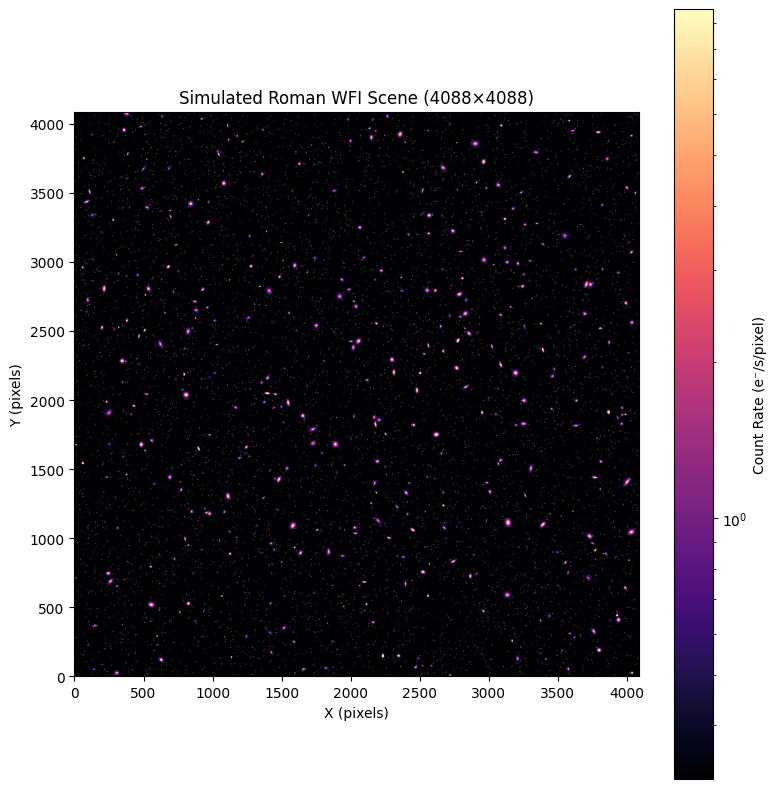

Scene saved to roman_wfi_scene_4088x4088.fits.fz


In [6]:
# Plot scene
fig = plot_scene(scene, title=f"Simulated Roman WFI Scene ({image_size}×{image_size})")
plt.tight_layout()
plt.show()

# Save the scene to a FITS file
from astropy.io import fits
import numpy as np

hdu = fits.PrimaryHDU(data=scene.astype(np.float32))
hdu.header['TELESCOP'] = 'Roman'
hdu.header['INSTRUME'] = 'WFI'
hdu.header['NAXIS1'] = image_size
hdu.header['NAXIS2'] = image_size
hdu.header['BUNIT'] = 'electrons'
hdu.header['COMMENT'] = f'Simulated Roman WFI Scene ({image_size}x{image_size})'

hdul = fits.HDUList([hdu])
fits_filename = f'roman_wfi_scene_{image_size}x{image_size}.fits.fz'
hdul.writeto(fits_filename, overwrite=True)
print(f"Scene saved to {fits_filename}")


0.315 23488.941426957794


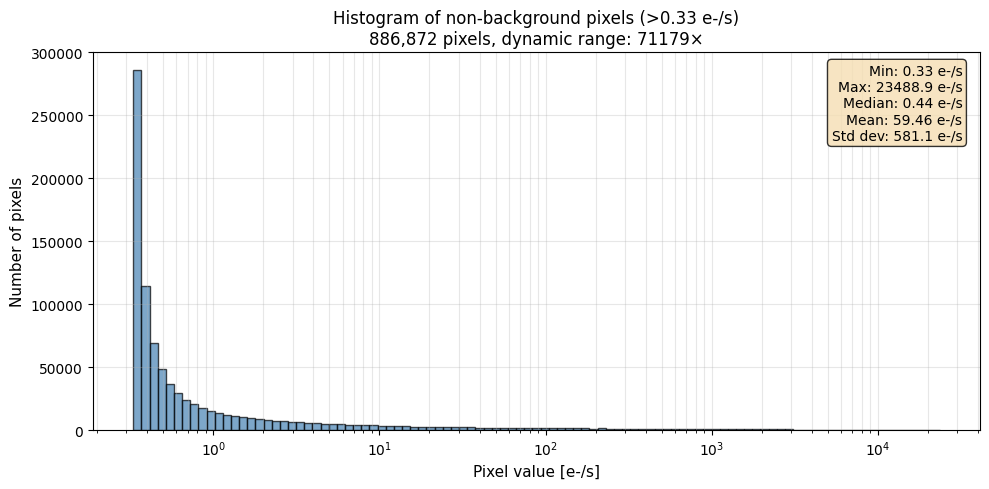

Non-background pixels: 886,872 (5.3% of all pixels)


In [7]:
print(scene.min(),scene.max())

# Histogram of non-background pixels in scene
bg_threshold = 0.33  # Background level in e-/s/pixel
non_bg = scene[scene > bg_threshold]

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram with logarithmic x-axis to capture the wide dynamic range
ax.hist(non_bg, bins=np.logspace(np.log10(non_bg.min()), np.log10(non_bg.max()), 100),
        edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Pixel value [e-/s]', fontsize=11)
ax.set_ylabel('Number of pixels', fontsize=11)
ax.set_title(f'Histogram of non-background pixels (>{bg_threshold} e-/s)\n'
             f'{len(non_bg):,} pixels, dynamic range: {non_bg.max()/non_bg.min():.0f}×', fontsize=12)
ax.grid(True, which='both', alpha=0.3)

# Add statistics box
stats_text = (f'Min: {non_bg.min():.2f} e-/s\n'
              f'Max: {non_bg.max():.1f} e-/s\n'
              f'Median: {np.median(non_bg):.2f} e-/s\n'
              f'Mean: {np.mean(non_bg):.2f} e-/s\n'
              f'Std dev: {np.std(non_bg):.1f} e-/s')
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Non-background pixels: {len(non_bg):,} ({100*len(non_bg)/scene.size:.1f}% of all pixels)")

## Step 6: Visualize CRNL Model

Show the power-law CRNL model and its fractional error.

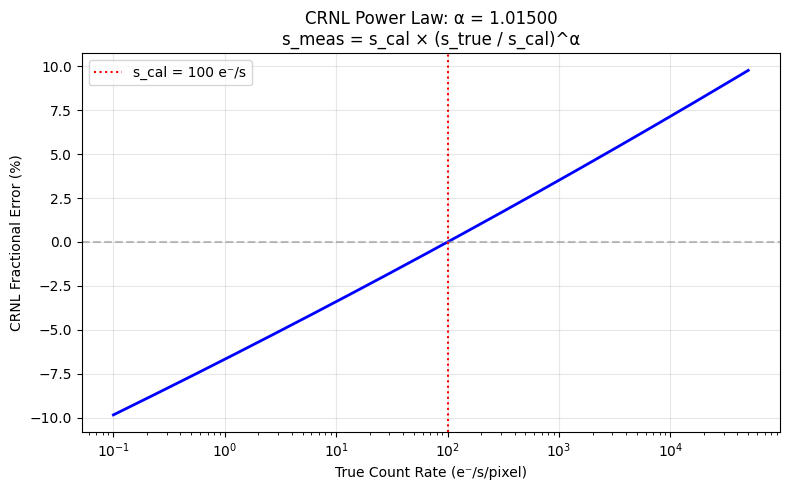

In [8]:
# Plot CRNL curve
fig = plot_crnl_curve(crnl_model, rate_range=(0.1, 50000))
plt.tight_layout()
plt.show()

## Step 7: Run Lamp-On/Lamp-Off Experiment

Observe the scene with and without the lamp pedestal at multiple flux levels.

In [9]:
# --- Dither pattern -----------------------------------------------------------
# 4 pointings: nominal → (+a,0) → (+a,+a) → (0,+a)
# side length a = 0.05 arcmin = 3.0 arcsec
# a = 0.05 * 60.0   # arcsec
# dither_offsets_arcsec = [
#     (0.0,  0.0),   # 1: nominal
#     ( +a,  0.0),   # 2: right
#     ( +a,  +a),   # 3: upper-right
#     (0.0,  +a),   # 4: upper
# ]

# following cal WG, maybe just 2 dithers is enough. Use asymmetric dither
a = 0.04 * 60.0   # arcsec
b = 0.08 * 60.0   # arcsec
dither_offsets_arcsec = [
    (0.0,  0.0),   # 1: nominal
    ( +a,  +b),   # 2: dithered
]

print("Dither pattern (arcsec):")
for i, (dx, dy) in enumerate(dither_offsets_arcsec):
    pix_scale = wfi.pixel_scale
    print(f"  Pointing {i+1}: dx={dx:+6.2f}\"  dy={dy:+6.2f}\""
          f"  → ({dx/pix_scale:+6.1f}, {dy/pix_scale:+6.1f}) pix")

print(f"\nPixel scale: {wfi.pixel_scale} arcsec/pix")
print(f"Side length: {a:.2f}\" = {a/wfi.pixel_scale:.1f} pix")

# --- Run dithered lamp-on/lamp-off experiment ---------------------------------
print("\nRunning dithered lamp-on/lamp-off experiment...")
dithered_results = simulator.dithered_lamp_on_off_experiment(
    scene=scene,
    dither_offsets_arcsec=dither_offsets_arcsec,
    pedestal_rates=pedestal_rates,
    apply_crnl=True,
    add_noise=True,
)
print("✓ Dithered experiment complete")
print(f"  Dithers:   {len(dithered_results['lamp_off'])}")
print(f"  Pedestals: {len(dithered_results['pedestal_rates'])}")
print(f"  lamp_off shape:  {dithered_results['lamp_off'][0].shape}")
print(f"  lamp_signal shape per (ped, dither): {dithered_results['lamp_signal'][0][0].shape}")

# --- Also run the original single-pointing experiment so downstream cells
#     (Steps 8–14) that reference `results` continue to work. ----------------
# print("\nRunning reference single-pointing experiment...")
# results = simulator.lamp_on_off_experiment(
#     scene=scene,
#     pedestal_rates=pedestal_rates,
#     n_repeats=3,
#     apply_crnl=True,
#     add_noise=True,
# )
# print("✓ Reference experiment complete")
# print(f"  Lamp-off shape:  {results['lamp_off'].shape}")
# print(f"  Lamp-on count:   {len(results['lamp_on'])}")


Dither pattern (arcsec):
  Pointing 1: dx= +0.00"  dy= +0.00"  → (  +0.0,   +0.0) pix
  Pointing 2: dx= +2.40"  dy= +4.80"  → ( +21.8,  +43.6) pix

Pixel scale: 0.11 arcsec/pix
Side length: 2.40" = 21.8 pix

Running dithered lamp-on/lamp-off experiment...
Dithered LOLO: 2 dithers × 3 pedestal(s)...
  Dither 1/2: (+0.00", +0.00") = (+0, +0) pix
  Dither 2/2: (+2.40", +4.80") = (+22, +44) pix
✓ Dithered experiment complete
  Dithers:   2
  Pedestals: 3
  lamp_off shape:  (4088, 4088)
  lamp_signal shape per (ped, dither): (4088, 4088)


In [10]:
# Export dithered LOLO dataset to FITS
fits_out = f'roman_wfi_dithered_lolo_{image_size}px.fits.fz'
save_dithered_to_fits(fits_out, dithered_results, crnl_model, wfi)

# Quick extension summary
from astropy.io import fits as _fits
with _fits.open(fits_out) as hdul:
    print(f"\nFITS extensions in {fits_out}:")
    for ext in hdul:
        name = ext.name
        shape = ext.data.shape if ext.data is not None else '—'
        print(f"  [{hdul.index_of(name):2d}] {name:<12}  {str(shape)}")

Saved dithered LOLO to roman_wfi_dithered_lolo_4088px.fits.fz  (15 image extensions, 2 dithers × 3 pedestals)

FITS extensions in roman_wfi_dithered_lolo_4088px.fits.fz:
  [ 0] PRIMARY       —
  [ 1] SCENE         (4088, 4088)
  [ 2] LOFF_D0       (4088, 4088)
  [ 3] LOFF_D1       (4088, 4088)
  [ 4] LON_P0D0      (4088, 4088)
  [ 5] LON_P0D1      (4088, 4088)
  [ 6] LON_P1D0      (4088, 4088)
  [ 7] LON_P1D1      (4088, 4088)
  [ 8] LON_P2D0      (4088, 4088)
  [ 9] LON_P2D1      (4088, 4088)
  [10] SIG_P0D0      (4088, 4088)
  [11] SIG_P0D1      (4088, 4088)
  [12] SIG_P1D0      (4088, 4088)
  [13] SIG_P1D1      (4088, 4088)
  [14] SIG_P2D0      (4088, 4088)
  [15] SIG_P2D1      (4088, 4088)


## Step 8: Source Photometry on a LOLO Image

Use `SourcePhotometry` from `roman-phot.py` to detect stars and measure their fluxes in a lamp-off frame and a lamp-on frame, then compare the recovered photometry to see the CRNL imprint.

In [11]:
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip
from astropy.io import fits
import numpy as np
from romanphot import SourcePhotometry

# PSF FWHM from the WFI detector model (1.36 pix at 0.11"/pix)
fwhm_pix = wfi.psf_fwhm_pixels
print(f"PSF FWHM: {fwhm_pix:.2f} pixels")

# ------------------------------------------------------------------
# Load lamp-off (dither 0) and highest-pedestal lamp-on from the
# dithered LOLO FITS produced in previous step.
# PED_00/01/02 are 0-indexed → PED_02 matches LON_P2D0.
# ------------------------------------------------------------------
fits_file = f'roman_wfi_dithered_lolo_{image_size}px.fits.fz'
with fits.open(fits_file) as hdul:
    img_off     = hdul['LOFF_D0'].data.astype(float)   # lamp-off, dither 0
    img_on      = hdul['LON_P2D0'].data.astype(float)  # lamp-on, pedestal 2, dither 0
    pedestal_hi = hdul[0].header['PED_02']             # 360 e-/s (index 2 matches P2)

print(f"\nLoaded '{fits_file}'")
print(f"  LOFF_D0  (lamp-off): shape={img_off.shape}, median={np.median(img_off):.2f} e-/s")
print(f"  LON_P2D0 (lamp-on):  shape={img_on.shape},  median={np.median(img_on):.2f} e-/s")
print(f"  Pedestal level: {pedestal_hi} e-/s/pix")




PSF FWHM: 1.36 pixels

Loaded 'roman_wfi_dithered_lolo_4088px.fits.fz'
  LOFF_D0  (lamp-off): shape=(4088, 4088), median=0.29 e-/s
  LON_P2D0 (lamp-on):  shape=(4088, 4088),  median=305.34 e-/s
  Pedestal level: 300.0 e-/s/pix


# Step 9: Per-pixel LOLO

Single-frame fit with:
- **Model**: `ratio_model_pixel(S_off, α, φ_p) = (1 + φ_p/s_true)^α` where `s_true = S_cal * (S_off/S_cal)^(1/α)`
- **Fit**: per-pixel (not binned), Poisson weights `σ_R = R·sqrt(1/N_on + 1/N_off)`
- **Bounds**: $\alpha \in [0.98, 1.02]$; $\phi_p \in [0.1, 10] \times \phi_p^{\text{init}}$
- **Global (scalar) $\phi_p$** — no dithers yet, so can't fit per-pixel map

PLot 1: 
$ \frac{R - 1}{\phi_p/x} $ (we divide by the predicted shape of R-1)

Plot 2:
$\Delta$ vs. $S^{\text{off}}$ in log-log

Pixels used: 52,568
Rate range : [32.4, 25493.0] e-/s
Median R   : 2.635300

=== FIT RESULTS ===
  alpha  = 1.014970 ± 0.000080   (true: 1.015000)
  phi_p  = 300.009 ± 0.058  e-/s   (true: 300.0)
  chi^2/dof = 0.454   (23846.8 / 52566)
  corr(alpha, phi_p) = -0.950


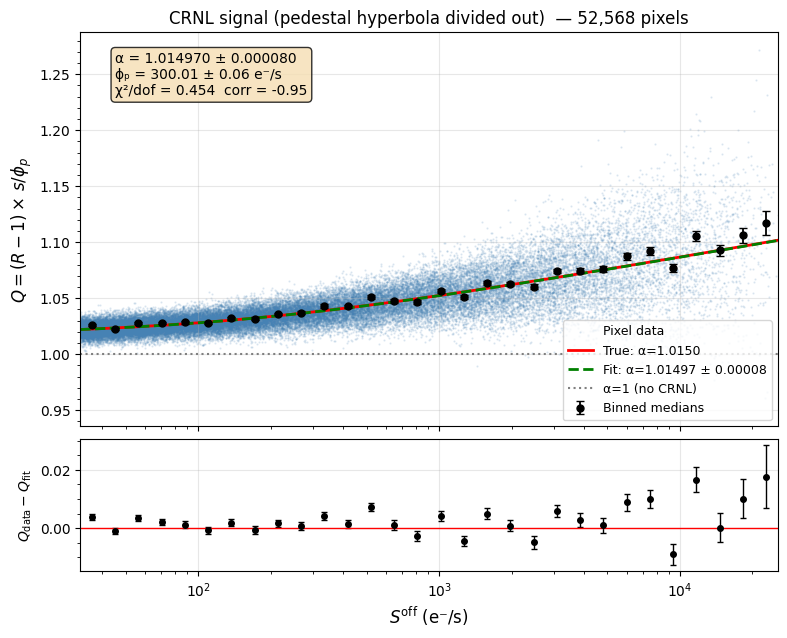

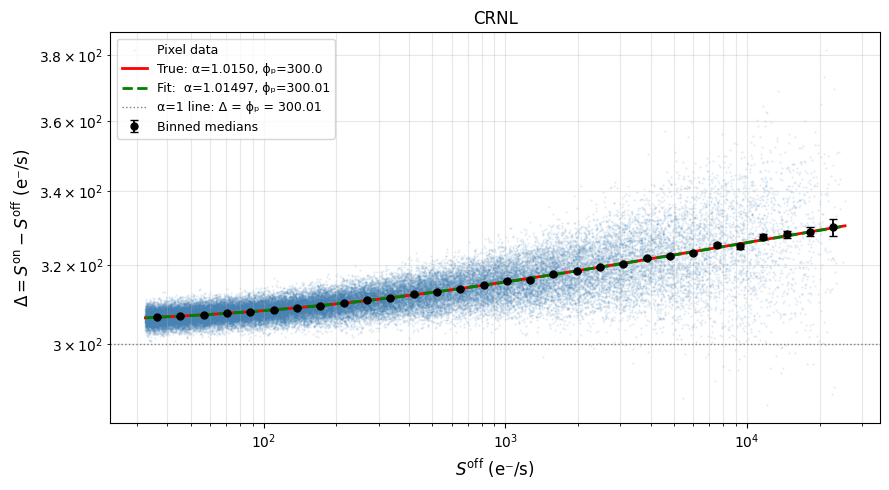


 Summary
  Observable    : R = S_on / S_off  (no bkg subtraction)
  Model         : R = (1 + phi_p / s_true)^alpha
                  S_true = S_cal * (S_off / S_cal)^(1/alpha)
  S_cal (pivot) : 100.00 e-/s
  Exposure time : 140.0 s
  N pixels      : 52,568

=== INPUT PARAMETERS ===
  alpha (true)  = 1.015
  phi_p (true)  = 300.0
  S_cal         = 100.0

=== FIT RESULTS ===
  alpha (fit)   = 1.014970 ± 0.000080
  phi_p (fit)   = 300.009 ± 0.058
  chi^2/dof     = 0.454
  corr(α, ϕₚ)   = -0.950

=== RESIDUAL STATISTICS ===
  pull mean     = +0.002   (should be ~0)
  pull std      = 0.674    (should be ~1)

=== RATE STATISTICS ===
  S_off: min=32.40, med=189.50, max=25493.00
  S_on : min=334.74, med=499.24, max=25830.38
  Delta: min=285.49, med=309.92, max=381.52
  R_obs: min=1.012645, med=2.635300, max=10.553259

=== BINNED DATA (R = S_on / S_off) ===
  bin_center        N     R_median        R_err        R_fit
       36.21     4111     9.501596     0.008477     9.470342
       45.23    

In [ ]:
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator


pedestal_true = pedestal_rates[-1] # highest pedestal for now

# ------------------------------------------------------------------
# 0. Model
# ------------------------------------------------------------------
def ratio_model_pixel(S_off, alpha_val, phi_p_val, S_cal=s_cal):
    """
    Exact per-pixel CRNL ratio, NO background subtraction.
        R = (1 + phi_p / s_true)^alpha,
        S_true = S_cal * (S_off / S_cal)^(1/alpha)
    """
    S_true = S_cal * (S_off / S_cal) ** (1.0 / alpha_val)
    return (1.0 + phi_p_val / S_true) ** alpha_val

def delta_model_exact(S_off, alpha_val, phi_p_val, S_cal=s_cal):
    """
    Exact Delta = S_on - S_off, from the CRNL model with no bkg subtraction.
    """
    S_true = S_cal * (S_off / S_cal) ** (1.0 / alpha_val)
    S_on   = S_cal * ((S_true + phi_p_val) / S_cal) ** alpha_val
    return S_on - S_off

# ------------------------------------------------------------------
# 1. Extract per-pixel rates and compute R = S_on / S_off
# ------------------------------------------------------------------
rate_off_2d = img_off       # e-/s, raw (NO bkg subtraction)
rate_on_2d  = img_on        # e-/s, raw

snr_cut = 3.0
bkg_noise_per_pix = np.sqrt(sky_bg*wfi.exposure_time)
good = (
    (np.abs(img_off) / bkg_noise_per_pix > snr_cut) &
    # (np.abs(img_on_sub)  / np.maximum(rms_on,  1e-10) > snr_cut) &
    (rate_off_2d > 1.0) &
    np.isfinite(rate_off_2d) &
    np.isfinite(rate_on_2d)
)


# main observable is the ratio for now
# maybe try the difference too?
rate_off = rate_off_2d[good]
rate_on  = rate_on_2d[good]
R_obs    = rate_on / rate_off

# Per-pixel Poisson uncertainty on R
# of course this is an oversimplification for now
t_exp   = wfi.exposure_time
sigma_R = R_obs * np.sqrt(1.0/(rate_on*t_exp) + 1.0/(rate_off*t_exp))

print(f"Pixels used: {good.sum():,}")
print(f"Rate range : [{rate_off.min():.1f}, {rate_off.max():.1f}] e-/s")
print(f"Median R   : {np.median(R_obs):.6f}")

# ------------------------------------------------------------------
# 2. Per-pixel joint fit for (alpha, phi_p)
# ------------------------------------------------------------------
p0     = [1.000, pedestal_hi]
bounds = ([0.98, 0.1*pedestal_hi], [1.02, 10.0*pedestal_hi])

popt, pcov = curve_fit(
    ratio_model_pixel, rate_off, R_obs,
    p0=p0, sigma=sigma_R, absolute_sigma=True,
    bounds=bounds, maxfev=50000,
)
alpha_fit, phi_p_fit = popt
alpha_err, phi_p_err = np.sqrt(np.diag(pcov))
corr = pcov[0, 1] / (alpha_err * phi_p_err)

# Goodness of fit
R_model_pix = ratio_model_pixel(rate_off, *popt)
chi2   = np.sum(((R_obs - R_model_pix) / sigma_R) ** 2)
ndof   = len(R_obs) - len(popt)
chi2_r = chi2 / ndof

print("\n=== FIT RESULTS ===")
print(f"  alpha  = {alpha_fit:.6f} ± {alpha_err:.6f}   (true: {alpha:.6f})")
print(f"  phi_p  = {phi_p_fit:.3f} ± {phi_p_err:.3f}  e-/s   (true: {pedestal_true:.1f})")
print(f"  chi^2/dof = {chi2_r:.3f}   ({chi2:.1f} / {ndof})")
print(f"  corr(alpha, phi_p) = {corr:+.3f}")


# ------------------------------------------------------------------
# 3. Binning (for visualization only, not for fitting)
# ------------------------------------------------------------------
n_bins    = 30
bin_edges = np.logspace(np.log10(rate_off.min()),
                        np.log10(rate_off.max()), n_bins + 1)
bin_ctrs  = np.sqrt(bin_edges[:-1] * bin_edges[1:])

R_median   = np.full(n_bins, np.nan)
R_err_bin  = np.full(n_bins, np.nan)
D_median   = np.full(n_bins, np.nan)
D_err_bin  = np.full(n_bins, np.nan)
Delta      = rate_on - rate_off

for i in range(n_bins):
    in_bin = (rate_off >= bin_edges[i]) & (rate_off < bin_edges[i+1])
    if in_bin.sum() > 20:
        R_median[i]  = np.median(R_obs[in_bin])
        R_err_bin[i] = np.std(R_obs[in_bin]) / np.sqrt(in_bin.sum())
        pos = Delta[in_bin] > 0
        if pos.sum() > 10:
            D_median[i]  = np.median(Delta[in_bin][pos])
            D_err_bin[i] = np.std(Delta[in_bin][pos]) / np.sqrt(pos.sum())

valid = np.isfinite(R_median)
valid_D = np.isfinite(D_median)


# ------------------------------------------------------------------
# 4. Model curves
# ------------------------------------------------------------------
rate_model    = np.logspace(np.log10(rate_off.min()),
                            np.log10(rate_off.max()), 200)
R_model_true  = ratio_model_pixel(rate_model, alpha,     pedestal_true, S_cal=s_cal)
R_model_fitc  = ratio_model_pixel(rate_model, alpha_fit, phi_p_fit,   S_cal=s_cal)

# NEW (exact, valid everywhere):
D_model_true = delta_model_exact(rate_model, alpha,     pedestal_true, S_cal=s_cal)
D_model_fit  = delta_model_exact(rate_model, alpha_fit, phi_p_fit,   S_cal=s_cal)


# ------------------------------------------------------------------
# Plot 1: Q = (R-1) * s / phi_p  — pedestal hyperbola divided out
# At alpha=1: Q = 1 exactly for all pixels. Deviations = pure CRNL.
# ------------------------------------------------------------------
Q_obs = (R_obs - 1.0) * rate_off / phi_p_fit
Q_med = (R_median - 1.0) * bin_ctrs / phi_p_fit
Q_err = R_err_bin * bin_ctrs / phi_p_fit
Q_true = (R_model_true - 1.0) * rate_model / pedestal_true
Q_fit  = (R_model_fitc - 1.0) * rate_model / phi_p_fit

# Shared s-range
s_min, s_max = rate_off.min(), rate_off.max()

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(9, 7),
                                      height_ratios=[3, 1],
                                      sharex=True,
                                      gridspec_kw={'hspace': 0.05})

# Scatter of individual pixels
ax_top.scatter(rate_off, Q_obs, s=0.4, alpha=0.15, c='steelblue',
               rasterized=True, label='Pixel data')

# Binned medians
ax_top.errorbar(bin_ctrs[valid], Q_med[valid], yerr=Q_err[valid],
                fmt='ko', ms=5, capsize=3, lw=1.3, zorder=5,
                label='Binned medians')

# Model curves
ax_top.plot(rate_model, Q_true, 'r-',  lw=2,
            label=f'True: α={alpha:.4f}')
ax_top.plot(rate_model, Q_fit,  'g--', lw=2,
            label=f'Fit: α={alpha_fit:.5f} ± {alpha_err:.5f}')
ax_top.axhline(1.0, color='gray', ls=':', lw=1.5,
               label='α=1 (no CRNL)')

# Fit results box
fit_text = (f'α = {alpha_fit:.6f} ± {alpha_err:.6f}\n'
            f'ϕₚ = {phi_p_fit:.2f} ± {phi_p_err:.2f} e⁻/s\n'
            f'χ²/dof = {chi2_r:.3f}  corr = {corr:+.2f}')
ax_top.text(0.05, 0.95, fit_text, transform=ax_top.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))


ax_top.set_xscale('log')
ax_top.set_xlim(s_min, s_max)
ax_top.set_ylabel(r'$Q = (R-1)\times\,s/\phi_p$', fontsize=12)
ax_top.set_title(f'CRNL signal (pedestal hyperbola divided out)  '
                 f'— {good.sum():,} pixels')
ax_top.legend(loc='lower right', fontsize=9)
ax_top.grid(True, alpha=0.3)
ax_top.yaxis.set_minor_locator(AutoMinorLocator())

# Residual panel — Q data minus Q at fit
Q_fit_at_bins = ((ratio_model_pixel(bin_ctrs, alpha_fit, phi_p_fit, S_cal=s_cal)
                  - 1.0) * bin_ctrs / phi_p_fit)
resid_Q = (Q_med - Q_fit_at_bins)
ax_bot.errorbar(bin_ctrs[valid], resid_Q[valid], yerr=Q_err[valid],
                fmt='ko', ms=4, capsize=2, lw=1)
ax_bot.axhline(0, color='r', ls='-', lw=1)
ax_bot.set_xscale('log')
ax_bot.set_xlim(s_min, s_max)
ax_bot.set_xlabel(r'$S^{\rm off}$ (e⁻/s)', fontsize=12)
ax_bot.set_ylabel(r'$Q_{\rm data} - Q_{\rm fit}$')
ax_bot.grid(True, alpha=0.3)
ax_bot.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.savefig('crnl_Q_vs_rate.png')
plt.show()

# ==================================================================
# PLOT 2: Delta = S_on - S_off vs S_off  (isolates alpha directly)
# ==================================================================
fig2, ax2 = plt.subplots(figsize=(9, 5))

pos_all = Delta > 0
ax2.scatter(rate_off[pos_all], Delta[pos_all], s=0.3, alpha=0.15,
            c='steelblue', rasterized=True, label='Pixel data')
ax2.errorbar(bin_ctrs[valid_D], D_median[valid_D], yerr=D_err_bin[valid_D],
             fmt='ko', ms=5, capsize=3, lw=1.3, zorder=5,
             label='Binned medians')
ax2.plot(rate_model, D_model_true, 'r-',  lw=2,
         label=f'True: α={alpha:.4f}, ϕₚ={pedestal_true:.1f}')
ax2.plot(rate_model, D_model_fit,  'g--', lw=2,
         label=f'Fit:  α={alpha_fit:.5f}, ϕₚ={phi_p_fit:.2f}')
ax2.axhline(phi_p_fit, color='gray', ls=':', lw=1,
            label=f'α=1 line: Δ = ϕₚ = {phi_p_fit:.2f}')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$S^{\rm off}$ (e⁻/s)', fontsize=12)
ax2.set_ylabel(r'$\Delta = S^{\rm on} - S^{\rm off}$ (e⁻/s)', fontsize=12)
ax2.set_title(r'CRNL')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('crnl_delta_vs_rate.png')
plt.show()


# ==================================================================
# Summary + diagnostics
# ==================================================================
print(f"\n{'='*60}")
print(f" Summary")
print(f"{'='*60}")
print(f"  Observable    : R = S_on / S_off  (no bkg subtraction)")
print(f"  Model         : R = (1 + phi_p / s_true)^alpha")
print(f"                  S_true = S_cal * (S_off / S_cal)^(1/alpha)")
print(f"  S_cal (pivot) : {s_cal:.2f} e-/s")
print(f"  Exposure time : {t_exp:.1f} s")
print(f"  N pixels      : {good.sum():,}")
print(f"{'='*60}")

print("\n=== INPUT PARAMETERS ===")
print(f"  alpha (true)  = {alpha}")
print(f"  phi_p (true)  = {pedestal_true}")
print(f"  S_cal         = {s_cal}")

print("\n=== FIT RESULTS ===")
print(f"  alpha (fit)   = {alpha_fit:.6f} ± {alpha_err:.6f}")
print(f"  phi_p (fit)   = {phi_p_fit:.3f} ± {phi_p_err:.3f}")
print(f"  chi^2/dof     = {chi2_r:.3f}")
print(f"  corr(α, ϕₚ)   = {corr:+.3f}")

print("\n=== RESIDUAL STATISTICS ===")
resid_all = (R_obs - R_model_pix) / sigma_R
print(f"  pull mean     = {np.mean(resid_all):+.3f}   (should be ~0)")
print(f"  pull std      = {np.std(resid_all):.3f}    (should be ~1)")

print("\n=== RATE STATISTICS ===")
print(f"  S_off: min={rate_off.min():.2f}, med={np.median(rate_off):.2f}, "
      f"max={rate_off.max():.2f}")
print(f"  S_on : min={rate_on.min():.2f}, med={np.median(rate_on):.2f}, "
      f"max={rate_on.max():.2f}")
print(f"  Delta: min={Delta.min():.2f}, med={np.median(Delta):.2f}, "
      f"max={Delta.max():.2f}")
print(f"  R_obs: min={R_obs.min():.6f}, med={np.median(R_obs):.6f}, "
      f"max={R_obs.max():.6f}")

print("\n=== BINNED DATA (R = S_on / S_off) ===")
print(f"{'bin_center':>12s} {'N':>8s} {'R_median':>12s} {'R_err':>12s} "
      f"{'R_fit':>12s}")
for i in range(n_bins):
    in_bin = (rate_off >= bin_edges[i]) & (rate_off < bin_edges[i+1])
    n_in = in_bin.sum()
    if n_in > 20:
        R_mod_i = ratio_model_pixel(bin_ctrs[i], alpha_fit, phi_p_fit,
                                     S_cal=s_cal)
        print(f"{bin_ctrs[i]:12.2f} {n_in:8d} "
              f"{R_median[i]:12.6f} {R_err_bin[i]:12.6f} {R_mod_i:12.6f}")

print("\n=== SANITY CHECKS ===")
print(f"  phi_p / min(S_off)  = {phi_p_fit / rate_off.min():.4f}   "
      f"(high signal regime)")
print(f"  phi_p / med(S_off)  = {phi_p_fit / np.median(rate_off):.4f}")
print(f"  phi_p / max(S_off)  = {phi_p_fit / rate_off.max():.6f}   "
      f"(low signal regime)")
print(f"  <Delta>             = {np.mean(Delta):.3f} e-/s")
print(f"  <Delta> at α=1 pred = {phi_p_fit:.3f} e-/s   (should match if α≈1)")

# Step 10 LOLO through aperture photometry == This doesn't work very well and needs more attention

In [13]:
# ------------------------------------------------------------------
# Background estimation and subtraction
# ------------------------------------------------------------------
sigma_clip    = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()

def estimate_bkg(image, box=64):
    b = Background2D(image, box_size=box, filter_size=3,
                     sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
    return b.background, b.background_rms

bkg_off, rms_off = estimate_bkg(img_off)
bkg_on,  rms_on  = estimate_bkg(img_on)

img_off_sub = img_off - bkg_off
img_on_sub  = img_on  - bkg_on
pedestal_hi = np.median(bkg_on) # this doesn't work if there is structure, so just a placeholder for now

print(f"\nBackground subtraction:")
print(f"  Lamp-off  bkg={np.median(bkg_off):.3f}, rms={np.median(rms_off):.3f} e-/s")
print(f"  Lamp-on   bkg={np.median(bkg_on):.3f}, rms={np.median(rms_on):.3f} e-/s")

# ------------------------------------------------------------------
# Source detection on the lamp-off frame
# ------------------------------------------------------------------
sp = SourcePhotometry(fwhm_pix=fwhm_pix, detection_sigma=5.0,
                      aperture_radius_fwhm=3.0,
                      annulus_inner_fwhm=4.0, annulus_outer_fwhm=6.0)

print(f"\nDetecting sources in lamp-off frame (threshold={sp.detection_sigma}σ)...")
sources = sp.detect_sources(img_off_sub, rms_off)

# ------------------------------------------------------------------
# DS9 support
# ------------------------------------------------------------------
# DS9 stuff that needs to happen on my computer if I want to display in DS9
# import pyds9
# ds9_bin = '/Applications/SAOImageDS9.app/Contents/MacOS/ds9'
# xpans_path = pyds9.ds9Globals['progs'][0]
# pyds9.ds9Globals['progs'] = (xpans_path, [ds9_bin])
# ds9 = sp.display_in_ds9(img_off_sub, sources=sources, title="Detected Sources in Lamp-Off Frame")


Background subtraction:
  Lamp-off  bkg=0.290, rms=0.097 e-/s
  Lamp-on   bkg=305.318, rms=1.463 e-/s

Detecting sources in lamp-off frame (threshold=5.0σ)...
  Detected 10488 sources above 5.0σ threshold


In [22]:
# ------------------------------------------------------------------
# Toggle between aperture and PSF photometry
# ------------------------------------------------------------------
use_psf_photometry = False  # Set to False for aperture photometry, which doesn't work well at all yet

if use_psf_photometry:
    print("Running PSF photometry on lamp-off frame...")
    phot_off = sp.psf_photometry_on_frame(img_off_sub, sources, rms_off)

    print("Running PSF photometry on lamp-on frame...")
    phot_on = sp.psf_photometry_on_frame(img_on_sub, sources, rms_on)

    # Compute SNR for PSF photometry
    def add_snr_to_psf_phot(phot_table):
        """Compute SNR for PSF photometry results."""
        if 'flux_err' not in phot_table.colnames:
            if 'cov_x_flux' in phot_table.colnames:
                phot_table['flux_err'] = np.sqrt(np.abs(phot_table['cov_x_flux']))
            else:
                phot_table['flux_err'] = 0.1 * np.abs(phot_table['flux_fit'])
        phot_table['snr'] = np.abs(phot_table['flux_fit']) / np.maximum(phot_table['flux_err'], 1e-10)
        return phot_table

    phot_off = add_snr_to_psf_phot(phot_off)
    phot_on = add_snr_to_psf_phot(phot_on)
    flux_col = 'flux_fit'
else:
    print("Running aperture photometry on lamp-off frame...")
    phot_off = sp.aperture_photometry_on_frame(img_off_sub, sources, rms_off, local_bkg_subtraction=False)

    print("Running aperture photometry on lamp-on frame...")
    phot_on = sp.aperture_photometry_on_frame(img_on_sub, sources, rms_on, local_bkg_subtraction=False)

    flux_col = 'flux_bkgsub'

print(f"\nPhotometry results: {len(phot_off)} sources")
print(f"Method: {'PSF photometry' if use_psf_photometry else 'Aperture photometry'}")
print(f"Flux column: {flux_col}")

# ------------------------------------------------------------------
# Flux-ratio analysis — SNR cut
# ------------------------------------------------------------------
snr_cut  = 5.0
good     = (phot_off['snr'] > snr_cut) & (phot_on['snr'] > snr_cut)
rate_off = np.array(phot_off[flux_col])[good]
rate_on  = np.array(phot_on[flux_col])[good]

print(f"rate_off.max() = {rate_off.max()}")
print(f"rate_off.min() = {rate_off.min()}")

# same as per pixel, ratio is main observable
ratio_obs = rate_on / rate_off


# ------------------------------------------------------------------
# CRNL-model expected ratio (background-subtracted images).
#
# Background subtraction removes the CRNL-distorted pedestal, i.e.
#   bkg_on ≈ s_cal * (pedestal / s_cal)^alpha
#
# So the measured source rate in each bkg-subtracted frame is:
#   rate_off ≈ s_cal * (S_true / s_cal)^alpha
#   rate_on  ≈ s_cal * ((S_true + ped) / s_cal)^alpha
#              - s_cal * (ped / s_cal)^alpha
#
# Invert lamp-off to recover S_true, then predict rate_on
# ------------------------------------------------------------------


def ratio_model_naive(S_off, alpha_val, phi_p, S_cal=s_cal):
    """
    Naive single-pixel CRNL ratio model (ignores PSF structure).
    Treats entire aperture as one pixel. For comparison only.
    """
    r_true = S_cal * (S_off / S_cal) ** (1.0 / alpha_val)
    ped_meas = S_cal * (phi_p / S_cal) ** alpha_val
    S_on_pred = S_cal * ((r_true + phi_p) / S_cal) ** alpha_val - ped_meas # subtract the pedestal
    return S_on_pred / S_off

ratio_crnl = ratio_model_naive(rate_off, alpha, pedestal_hi, s_cal)

# Residual relative to the CRNL model (should be noise-dominated if model is right)
crnl_residual_pct = (ratio_obs / ratio_crnl - 1.0) * 100.0

# Linear reference (alpha=1): pedestal subtracts exactly, ratio = 1
ratio_linear = np.ones_like(rate_off)

print(f"\nFlux-ratio comparison ({good.sum()} sources, SNR > {snr_cut}):")
print(f"  Median ratio_obs:           {np.median(ratio_obs):.4f}")
print(f"  Median ratio_crnl (model):  {np.median(ratio_crnl):.4f}")
print(f"  Median ratio_linear (naive):{np.median(ratio_linear):.4f}")
print(f"\n  Residual vs CRNL model:  {np.median(crnl_residual_pct):+.3f}% ± {np.std(crnl_residual_pct):.3f}%  (should be ~0)")


Running aperture photometry on lamp-off frame...
Running aperture photometry on lamp-on frame...

Photometry results: 10488 sources
Method: Aperture photometry
Flux column: flux_bkgsub
rate_off.max() = 63236.504915293335
rate_off.min() = 41.56469980882564

Flux-ratio comparison (7275 sources, SNR > 5.0):
  Median ratio_obs:           1.0155
  Median ratio_crnl (model):  1.0074
  Median ratio_linear (naive):1.0000

  Residual vs CRNL model:  +0.854% ± 4.666%  (should be ~0)


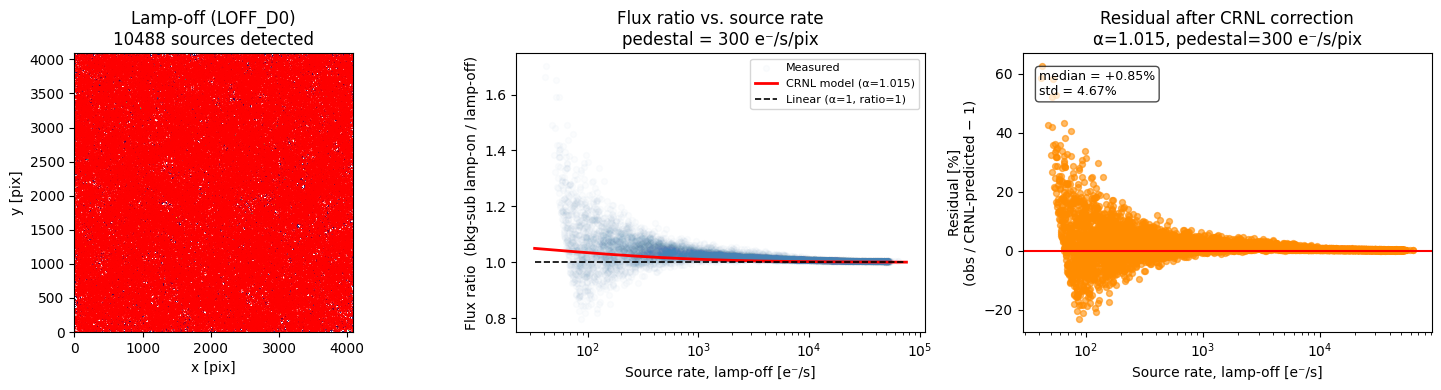

In [23]:
# ------------------------------------------------------------------
# Diagnostic plots
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Smooth model curves over the full detected rate range
r_curve      = np.geomspace(rate_off.min() * 0.8, rate_off.max() * 1.2, 300)
ratio_naive_curve = ratio_model_naive(r_curve, alpha, pedestal_true, s_cal)
# Linear (α=1): pedestal subtracts exactly → ratio = 1 for all source rates
ratio_linear_curve = np.ones_like(r_curve)

# Panel 1: lamp-off image with detected sources overlaid
ax = axes[0]
vmin, vmax = np.percentile(img_off_sub[img_off_sub > 0], [1, 99])
ax.imshow(img_off_sub, origin='lower', norm=LogNorm(vmin=max(vmin, 0.1), vmax=vmax),
          cmap='viridis', interpolation='nearest')
ax.scatter(sources['xcentroid'], sources['ycentroid'],
           s=30, facecolors='none', edgecolors='red', linewidths=0.8)
ax.set_title(f'Lamp-off (LOFF_D0)\n{len(sources)} sources detected')
ax.set_xlabel('x [pix]'); ax.set_ylabel('y [pix]')

# Panel 2: observed ratio vs. source rate with model curves
ax = axes[1]
ax.scatter(rate_off, ratio_obs, s=18, alpha=0.02, color='steelblue', label='Measured')
ax.plot(r_curve, ratio_naive_curve,   'r-',  lw=2,   label=f'CRNL model (α={alpha})')
ax.plot(r_curve, ratio_linear_curve, 'k--', lw=1.2, label='Linear (α=1, ratio=1)')
ax.set_xscale('log')
ax.set_xlabel('Source rate, lamp-off [e⁻/s]')
ax.set_ylabel('Flux ratio  (bkg-sub lamp-on / lamp-off)')
ax.set_title(f'Flux ratio vs. source rate\npedestal = {pedestal_true:.0f} e⁻/s/pix')
ax.legend(fontsize=8)

# Panel 3: residual after removing CRNL model prediction
ax = axes[2]
ax.scatter(rate_off, crnl_residual_pct, s=18, alpha=0.6, color='darkorange')
ax.axhline(0, color='r', lw=1.5, ls='-')
ax.set_xscale('log')
ax.set_xlabel('Source rate, lamp-off [e⁻/s]')
ax.set_ylabel('Residual [%]\n(obs / CRNL-predicted − 1)')
ax.set_title(f'Residual after CRNL correction\nα={alpha}, pedestal={pedestal_true:.0f} e⁻/s/pix')
med = np.median(crnl_residual_pct)
std = np.std(crnl_residual_pct)
ax.text(0.04, 0.94, f'median = {med:+.2f}%\nstd = {std:.2f}%',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()


# Fancy fit function that uses helper functions for the aperture correction

In [16]:
from scipy.optimize import least_squares

# ------------------------------------------------------------------
# CRNL fitter: estimate alpha (and optionally pedestal) from ratios
# ------------------------------------------------------------------

def fit_crnl_alpha(rate_off, ratio_obs, w_arr, S_cal,
                   phi_p_init, alpha_init=1.0,
                   fit_pedestal=False,
                   sigma=None,
                   bounds_alpha=(0.90, 1.10),
                   bounds_phi_p=(1e-4, 10.0),
                   verbose=True):
    """
    Fit the CRNL power-law index alpha from observed lamp-on/lamp-off
    ratios using the exact aperture-photometry model.

    Model:
        ratio_pred_j = S_on_pred_j(alpha, phi_p) / S_off_j
      where S_on_pred uses invert_rate_off_aperture + predict_rate_on_aperture.

    Parameters
    ----------
    rate_off, ratio_obs : arrays (M,)
        Measured lamp-off aperture rate and observed on/off ratio.
    w_arr : array (N_pix,)
        Normalized PSF weights (from make_psf_weights).
    S_cal : float
        Reference calibration rate s_cal.
    phi_p_init : float
        Initial guess for per-pixel pedestal rate (e-/s/pix).
    alpha_init : float
        Initial guess for alpha.
    fit_pedestal : bool
        If True, jointly fit (alpha, phi_p). Otherwise fix phi_p = phi_p_init.
    sigma : array (M,) or None
        Per-source uncertainty on ratio_obs (for weighted fit).
    bounds_alpha, bounds_phi_p : tuple
        Parameter bounds.

    Returns
    -------
    result : dict with keys
        alpha, alpha_err, phi_p, phi_p_err, chi2, dof, cov, success, message
    """
    rate_off  = np.asarray(rate_off, float)
    ratio_obs = np.asarray(ratio_obs, float)
    M = len(rate_off)

    if sigma is None:
        sigma = np.ones(M)
    sigma = np.asarray(sigma, float)

    def residuals(theta):
        if fit_pedestal:
            a, pp = theta
        else:
            a  = theta[0]
            pp = phi_p_init
        Phi_star   = invert_rate_off_aperture(rate_off, a, w_arr, S_cal)
        S_on_pred  = predict_rate_on_aperture(Phi_star, a, w_arr, pp, S_cal)
        ratio_pred = S_on_pred / rate_off
        return (ratio_obs - ratio_pred) / sigma

    if fit_pedestal:
        x0     = np.array([alpha_init, phi_p_init])
        lb     = np.array([bounds_alpha[0], bounds_phi_p[0]])
        ub     = np.array([bounds_alpha[1], bounds_phi_p[1]])
    else:
        x0     = np.array([alpha_init])
        lb     = np.array([bounds_alpha[0]])
        ub     = np.array([bounds_alpha[1]])

    res = least_squares(residuals, x0, bounds=(lb, ub), method='trf',
                        x_scale='jac', verbose=0)

    # Covariance estimate: (J^T J)^-1 * chi2/dof
    J    = res.jac
    dof  = max(M - len(x0), 1)
    chi2 = float(np.sum(res.fun**2))
    try:
        cov = np.linalg.inv(J.T @ J) * (chi2 / dof)
        perr = np.sqrt(np.diag(cov))
    except np.linalg.LinAlgError:
        cov, perr = None, np.full(len(x0), np.nan)

    out = {
        'alpha':     float(res.x[0]),
        'alpha_err': float(perr[0]),
        'phi_p':     float(res.x[1]) if fit_pedestal else float(phi_p_init),
        'phi_p_err': float(perr[1]) if fit_pedestal else 0.0,
        'chi2':      chi2,
        'dof':       dof,
        'cov':       cov,
        'success':   bool(res.success),
        'message':   res.message,
        'nfev':      res.nfev,
    }

    if verbose:
        print(f"CRNL fit ({'alpha + phi_p' if fit_pedestal else 'alpha only'}):")
        print(f"  alpha  = {out['alpha']:.6f} ± {out['alpha_err']:.6f}")
        if fit_pedestal:
            print(f"  phi_p  = {out['phi_p']:.4f} ± {out['phi_p_err']:.4f} e-/s/pix")
        print(f"  chi2/dof = {chi2:.3f} / {dof} = {chi2/dof:.3f}")
        print(f"  success = {out['success']} ({res.nfev} evals)")

    return out

# Fit with an aperture correction

In [ ]:
# ------------------------------------------------------------------
# Toggle between aperture and PSF photometry
# ------------------------------------------------------------------
use_psf_photometry = False  # Set to False for aperture photometry

# ------------------------------------------------------------------
# PSF weight computation for aperture-corrected CRNL model
#
# The CRNL is a per-pixel effect, but photometry sums over pixels
# with different rates. The aperture-summed CRNL is NOT equivalent
# to applying CRNL to the summed flux. We need the PSF pixel weights
# w_i (fraction of total source flux in pixel i) to correctly model
# how CRNL propagates through the photometric extraction.
# ------------------------------------------------------------------

def make_psf_weights(sigma_pix, r_ap_pix, oversample=1):
    """
    Generate normalized PSF weights for a Gaussian PSF in a circular aperture.
    
    Parameters
    ----------
    sigma_pix : float
        PSF sigma in pixels
    r_ap_pix : float
        Aperture radius in pixels
    oversample : int
        Sub-pixel oversampling factor (1 = pixel centers only)
    
    Returns
    -------
    w_arr : 1D array
        Normalized PSF weights (sum = 1) for pixels within aperture
    N_pix : int
        Number of pixels in aperture
    coords : tuple of arrays
        (x, y) pixel coordinates relative to center
    """
    r_max = int(np.ceil(r_ap_pix))
    yy, xx = np.mgrid[-r_max:r_max+1, -r_max:r_max+1]
    rr = np.sqrt(xx**2 + yy**2)
    
    # Mask: pixels within circular aperture
    in_ap = rr <= r_ap_pix
    
    # Gaussian PSF evaluated at pixel centers
    psf_vals = np.exp(-0.5 * rr**2 / sigma_pix**2)
    
    # Extract and normalize so sum(w_i) = 1
    w_arr = psf_vals[in_ap].astype(float)
    w_arr /= w_arr.sum()
    
    coords = (xx[in_ap], yy[in_ap])
    
    return w_arr, len(w_arr), coords


# --- PSF / aperture configuration (match your instrument) ---
psf_sigma_pix = wfi.psf_sigma_pixels    # PSF Gaussian sigma [pixels]
aperture_r_pix = sp.aperture_radius   # Circular aperture radius [pixels]

w_arr, N_pix_ap, pix_coords = make_psf_weights(psf_sigma_pix, aperture_r_pix)

# PSF diagnostic quantities
H_psf = -np.sum(w_arr * np.log(w_arr))                         # flux-weighted entropy
mean_ln_w = np.mean(np.log(w_arr))                              # arithmetic mean of log-weights
W_alpha_nom = np.sum(w_arr ** alpha)                            # PSF shape factor at nominal alpha
encircled_energy = np.sum(w_arr)                                # should be 1.0 by construction

print(f"PSF / Aperture Configuration:")
print(f"  PSF σ           = {psf_sigma_pix} pixels")
print(f"  Aperture radius = {aperture_r_pix} pixels")
print(f"  N pixels in ap  = {N_pix_ap}")
print(f"  H_PSF (entropy) = {H_psf:.4f}")
print(f"  <ln w> (arith)  = {mean_ln_w:.4f}")
print(f"  W_α(α={alpha})  = {W_alpha_nom:.6f}")
print(f"  Expected intercept offset = α·<ln w> ≈ {(alpha-1)*mean_ln_w:.5f}")
print()

# ------------------------------------------------------------------
# Photometry execution
# ------------------------------------------------------------------
if use_psf_photometry:
    print("Running PSF photometry on lamp-off frame...")
    phot_off = sp.psf_photometry_on_frame(img_off_sub, sources, rms_off)

    print("Running PSF photometry on lamp-on frame...")
    phot_on = sp.psf_photometry_on_frame(img_on_sub, sources, rms_on)

    # Compute SNR for PSF photometry
    def add_snr_to_psf_phot(phot_table):
        """Compute SNR for PSF photometry results."""
        if 'flux_err' not in phot_table.colnames:
            if 'cov_x_flux' in phot_table.colnames:
                phot_table['flux_err'] = np.sqrt(np.abs(phot_table['cov_x_flux']))
            else:
                phot_table['flux_err'] = 0.1 * np.abs(phot_table['flux_fit'])
        phot_table['snr'] = np.abs(phot_table['flux_fit']) / np.maximum(phot_table['flux_err'], 1e-10)
        return phot_table

    phot_off = add_snr_to_psf_phot(phot_off)
    phot_on = add_snr_to_psf_phot(phot_on)
    flux_col = 'flux_fit'
else:
    print("Running aperture photometry on lamp-off frame...")
    phot_off = sp.aperture_photometry_on_frame(img_off_sub, sources, rms_off, local_bkg_subtraction=False)

    print("Running aperture photometry on lamp-on frame...")
    phot_on = sp.aperture_photometry_on_frame(img_on_sub, sources, rms_on, local_bkg_subtraction=False)

    flux_col = 'flux_bkgsub'

print(f"\nPhotometry results: {len(phot_off)} sources")
print(f"Method: {'PSF photometry' if use_psf_photometry else 'Aperture photometry'}")
print(f"Flux column: {flux_col}")

# ------------------------------------------------------------------
# Flux-ratio analysis — SNR cut
# ------------------------------------------------------------------
snr_cut  = 5.0
good     = (phot_off['snr'] > snr_cut) & (phot_on['snr'] > snr_cut)
rate_off = np.array(phot_off[flux_col])[good]
rate_on  = np.array(phot_on[flux_col])[good]

print(f"\nSource rate range: [{rate_off.min():.2f}, {rate_off.max():.2f}] e⁻/s")

ratio_obs = rate_on / rate_off

# ------------------------------------------------------------------
# CRNL model: Exact per-pixel aperture-photometry prediction
#
# The CRNL is a PER-PIXEL nonlinearity:
#   S_i = S_cal * (phi_i / S_cal)^alpha
#
# For aperture photometry, the measured flux is the SUM over all
# pixels in the aperture. Each pixel sees a different true rate
# (PSF-weighted source + flat pedestal), so the aperture sum ≠
# CRNL applied to the total flux.
#
# Key quantities:
#   W_alpha = sum_i(w_i^alpha)  -- PSF shape factor
#   S_off = S_cal * (Phi_*/S_cal)^alpha * W_alpha
#
# We invert S_off to recover Phi_*, then predict the exact
# aperture-summed lamp-on rate pixel-by-pixel.
# ------------------------------------------------------------------

def invert_rate_off_aperture(S_off, alpha_val, w_arr, S_cal):
    """
    Invert the aperture-summed lamp-off measurement to recover
    the total true source flux Phi_*.
    
    S_off = S_cal * (Phi_* / S_cal)^alpha * W_alpha
    => Phi_* = S_cal * (S_off / (S_cal * W_alpha))^(1/alpha)
    """
    W_alpha = np.sum(w_arr ** alpha_val)
    Phi_star = S_cal * (S_off / (S_cal * W_alpha)) ** (1.0 / alpha_val)
    return Phi_star


def predict_rate_on_aperture(Phi_star, alpha_val, w_arr, phi_p, S_cal):
    """
    Predict the aperture-summed, bkg-subtracted lamp-on rate.
    
    For each pixel i:
      rate_on_i  = S_cal * ((w_i*Phi_* + phi_p) / S_cal)^alpha
      rate_bkg_i = S_cal * (phi_p / S_cal)^alpha
    
    S_on = sum_i [rate_on_i - rate_bkg_i]
    
    Parameters
    ----------
    Phi_star : array (M,)
        Total true source flux per source
    alpha_val : float
        CRNL power-law exponent
    w_arr : array (N_pix,)
        Normalized PSF weights
    phi_p : float
        Per-pixel pedestal rate (e-/s/pix)
    S_cal : float
        Reference calibration rate
        
    Returns
    -------
    S_on : array (M,)
        Predicted aperture-summed bkg-subtracted lamp-on rate
    """
    Phi_star = np.atleast_1d(Phi_star).astype(float)
    
    # Per-pixel source rates: (N_pix, M)
    phi_star_i = w_arr[:, None] * Phi_star[None, :]
    
    # Per-pixel lamp-on (source + pedestal)
    rate_on_i = S_cal * ((phi_star_i + phi_p) / S_cal) ** alpha_val
    
    # Per-pixel pedestal-only (removed by bkg subtraction)
    rate_bkg_i = S_cal * (phi_p / S_cal) ** alpha_val  # scalar, broadcasts
    
    # Aperture sum of bkg-subtracted lamp-on
    S_on = np.sum(rate_on_i - rate_bkg_i, axis=0)
    
    return S_on


def ratio_model_aperture(S_off, alpha_val, w_arr, phi_p, S_cal):
    """
    Exact aperture-photometry CRNL ratio model.
    
    Returns predicted ratio = S_on(bkg-sub) / S_off for each source.
    """
    Phi_star = invert_rate_off_aperture(S_off, alpha_val, w_arr, S_cal)
    S_on_pred = predict_rate_on_aperture(Phi_star, alpha_val, w_arr, phi_p, S_cal)
    return S_on_pred / S_off





# ------------------------------------------------------------------
# Compute model predictions
# ------------------------------------------------------------------

if use_psf_photometry:
    # PSF photometry: the fit effectively deconvolves PSF shape,
    # so the naive single-pixel model is a better approximation.
    # (The CRNL still causes a subtle weighted-sum bias, but it is
    #  much smaller because PSF fitting upweights high-SNR central pixels.)
    print("\nNote: PSF photometry partially accounts for PSF structure.")
    print("      Using naive model (single-pixel approximation).")
    
    r_true       = s_cal * (rate_off / s_cal) ** (1.0 / alpha)
    ped_meas     = s_cal * (pedestal_hi / s_cal) ** alpha
    rate_on_pred = s_cal * ((r_true + pedestal_hi) / s_cal) ** alpha - ped_meas
    ratio_crnl   = rate_on_pred / rate_off

else:
    # Aperture photometry: use exact per-pixel model
    print("\nUsing exact aperture-photometry CRNL model (per-pixel PSF weights).")
    
    # Recover true total source flux from lamp-off aperture sums
    Phi_star = invert_rate_off_aperture(rate_off, alpha, w_arr, s_cal)
    
    # Predict bkg-subtracted lamp-on aperture sum
    rate_on_pred = predict_rate_on_aperture(Phi_star, alpha, w_arr, pedestal_hi, s_cal)
    
    # Model ratio
    ratio_crnl = rate_on_pred / rate_off
    
    # Also compute naive model for comparison
    ratio_naive = ratio_model_naive(rate_off, alpha, pedestal_hi, s_cal)
    
    # Quantify bias from naive model
    bias_naive_pct = (ratio_naive - ratio_crnl) / ratio_crnl * 100.0
    print(f"  Naive model bias: median = {np.median(bias_naive_pct):+.4f}%, "
          f"max = {np.max(np.abs(bias_naive_pct)):.4f}%")

# ------------------------------------------------------------------
# Residuals
# ------------------------------------------------------------------
crnl_residual_pct = (ratio_obs / ratio_crnl - 1.0) * 100.0

# Linear reference (alpha=1): pedestal subtracts exactly, ratio = 1
ratio_linear = np.ones_like(rate_off)

print(f"\nFlux-ratio comparison ({good.sum()} sources, SNR > {snr_cut}):")
print(f"  Median ratio_obs:              {np.median(ratio_obs):.6f}")
print(f"  Median ratio_crnl (model):     {np.median(ratio_crnl):.6f}")
if not use_psf_photometry:
    print(f"  Median ratio_naive (no PSF):   {np.median(ratio_naive):.6f}")
print(f"  Median ratio_linear (α=1):     {np.median(ratio_linear):.6f}")
print(f"\n  Residual vs CRNL model:  {np.median(crnl_residual_pct):+.4f}% ± "
      f"{np.std(crnl_residual_pct):.4f}%  (expect ~0)")
if not use_psf_photometry:
    crnl_residual_naive_pct = (ratio_obs / ratio_naive - 1.0) * 100.0
    print(f"  Residual vs naive model: {np.median(crnl_residual_naive_pct):+.4f}% ± "
          f"{np.std(crnl_residual_naive_pct):.4f}%  (shows PSF bias)")


# Use SNR-scaled sigma if you have flux errors; else unit weights
sigma_ratio = None  # or: ratio_obs * np.sqrt(1/snr_off**2 + 1/snr_on**2)

fit = fit_crnl_alpha(
    rate_off, ratio_obs, w_arr, S_cal=s_cal,
    phi_p_init=pedestal_hi, alpha_init=1.,
    fit_pedestal=False,          # start simple
    sigma=sigma_ratio, bounds_phi_p = (0.95*pedestal_hi, 1.05*pedestal_hi)
)

PSF / Aperture Configuration:
  PSF σ           = 0.5790387955993052 pixels
  Aperture radius = 4.090909090909091 pixels
  N pixels in ap  = 49
  H_PSF (entropy) = 1.7152
  <ln w> (arith)  = -12.4371
  W_α(α=1.015)  = 0.974727
  Expected intercept offset = α·<ln w> ≈ -0.18656

Running aperture photometry on lamp-off frame...
Running aperture photometry on lamp-on frame...

Photometry results: 10488 sources
Method: Aperture photometry
Flux column: flux_bkgsub

Source rate range: [41.56, 63236.50] e⁻/s

Using exact aperture-photometry CRNL model (per-pixel PSF weights).
  Naive model bias: median = -1.4032%, max = 2.4213%

Flux-ratio comparison (7275 sources, SNR > 5.0):
  Median ratio_obs:              1.015530
  Median ratio_crnl (model):     1.021714
  Median ratio_naive (no PSF):   1.007377
  Median ratio_linear (α=1):     1.000000

  Residual vs CRNL model:  -0.0047% ± 4.4432%  (expect ~0)
  Residual vs naive model: +0.8539% ± 4.6658%  (shows PSF bias)
CRNL fit (alpha only):
  alpha

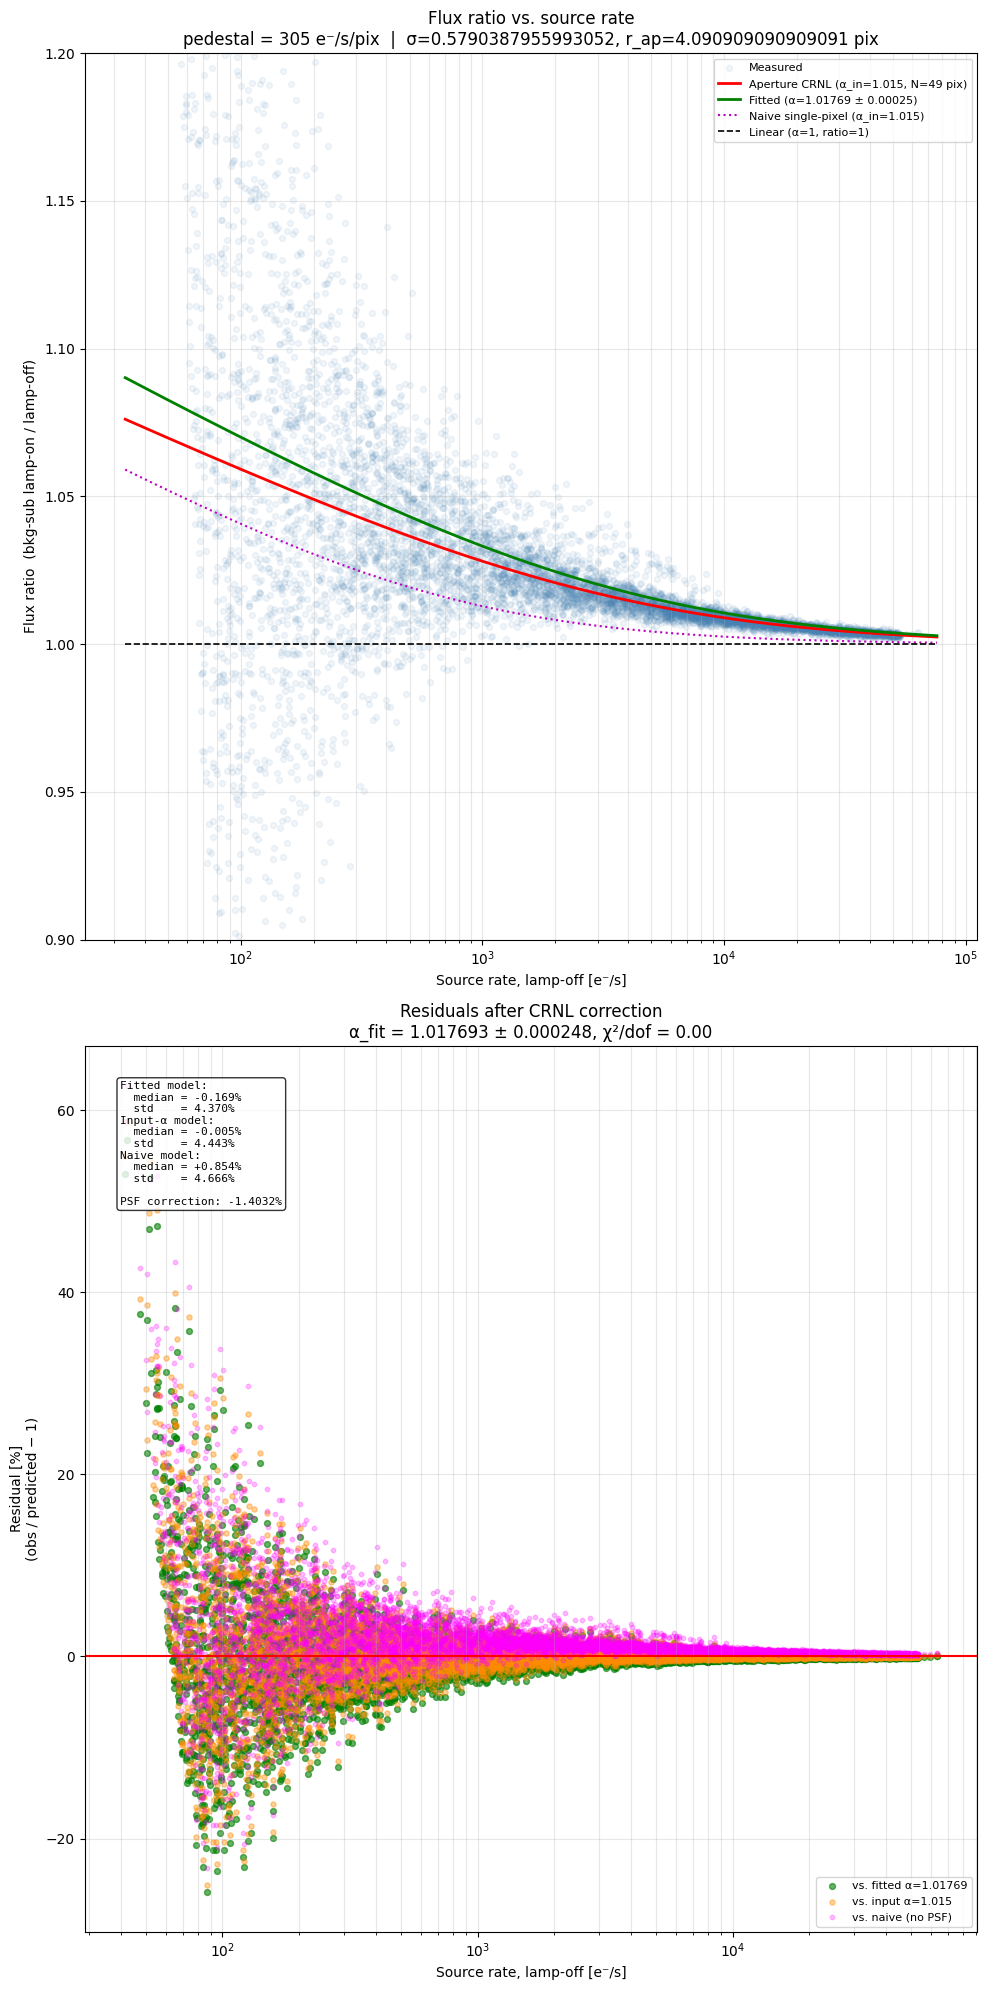

In [18]:
alpha_fit     = fit['alpha']
alpha_fit_err = fit['alpha_err']

# Model prediction at fitted alpha (for residuals)
if use_psf_photometry:
    r_true_fit       = s_cal * (rate_off / s_cal) ** (1.0 / alpha_fit)
    ped_meas_fit     = s_cal * (pedestal_hi / s_cal) ** alpha_fit
    rate_on_pred_fit = s_cal * ((r_true_fit + pedestal_hi) / s_cal) ** alpha_fit - ped_meas_fit
    ratio_fit        = rate_on_pred_fit / rate_off
else:
    ratio_fit = ratio_model_aperture(rate_off, alpha_fit, w_arr, pedestal_hi, s_cal)

fit_residual_pct = (ratio_obs / ratio_fit - 1.0) * 100.0

# ------------------------------------------------------------------
# Diagnostic plots (aperture-aware CRNL model + fit)
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 20))

# Smooth model curves over the full detected rate range
r_curve = np.geomspace(rate_off.min() * 0.8, rate_off.max() * 1.2, 300)

if use_psf_photometry:
    r_true_curve = s_cal * (r_curve / s_cal) ** (1.0 / alpha)
    ratio_crnl_curve = (
        s_cal * ((r_true_curve + pedestal_hi) / s_cal) ** alpha - ped_meas
    ) / r_curve
    r_true_curve_fit = s_cal * (r_curve / s_cal) ** (1.0 / alpha_fit)
    ped_meas_fit_c   = s_cal * (pedestal_hi / s_cal) ** alpha_fit
    ratio_fit_curve  = (
        s_cal * ((r_true_curve_fit + pedestal_hi) / s_cal) ** alpha_fit - ped_meas_fit_c
    ) / r_curve
    ratio_naive_curve = None
else:
    ratio_crnl_curve  = ratio_model_aperture(r_curve, alpha,     w_arr, pedestal_hi, s_cal)
    ratio_fit_curve   = ratio_model_aperture(r_curve, alpha_fit, w_arr, pedestal_hi, s_cal)
    ratio_naive_curve = ratio_model_naive(r_curve, alpha_fit, pedestal_hi, s_cal)

ratio_linear_curve = np.ones_like(r_curve)

# --- Panel 1 (was panel 2): observed ratio vs. source rate with model curves ---
ax = axes[0]
ax.scatter(rate_off, ratio_obs, s=18, alpha=0.08, color='steelblue', label='Measured')
ax.plot(r_curve, ratio_crnl_curve, 'r-', lw=2,
        label=f'Aperture CRNL (α_in={alpha}, N={N_pix_ap} pix)' if not use_psf_photometry
        else f'CRNL model (α_in={alpha})')
ax.plot(r_curve, ratio_fit_curve, 'g-', lw=2,
        label=f'Fitted (α={alpha_fit:.5f} ± {alpha_fit_err:.5f})')
if ratio_naive_curve is not None:
    ax.plot(r_curve, ratio_naive_curve, 'm:', lw=1.5,
            label=f'Naive single-pixel (α_in={alpha})')
ax.plot(r_curve, ratio_linear_curve, 'k--', lw=1.2, label='Linear (α=1, ratio=1)')
ax.set_xscale('log')
ax.set_xlabel('Source rate, lamp-off [e⁻/s]')
ax.set_ylabel('Flux ratio  (bkg-sub lamp-on / lamp-off)')
ax.set_title(f'Flux ratio vs. source rate\npedestal = {pedestal_hi:.0f} e⁻/s/pix'
             + (f'  |  σ={psf_sigma_pix}, r_ap={aperture_r_pix} pix'
                if not use_psf_photometry else ''))
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(0.9, 1.2)

# --- Panel 2 (was panel 3): residuals ---
ax = axes[1]

# Residual vs fitted model (primary)
ax.scatter(rate_off, fit_residual_pct, s=18, alpha=0.6, color='green',
           label=f'vs. fitted α={alpha_fit:.5f}')

# Residual vs input-alpha aperture-corrected model
ax.scatter(rate_off, crnl_residual_pct, s=14, alpha=0.4, color='darkorange',
           label=f'vs. input α={alpha}')

# Residual vs naive model (aperture photometry only)
if not use_psf_photometry:
    ax.scatter(rate_off, crnl_residual_naive_pct, s=10, alpha=0.25, color='magenta',
               label='vs. naive (no PSF)')

ax.axhline(0, color='r', lw=1.5, ls='-')
ax.set_xscale('log')
ax.set_xlabel('Source rate, lamp-off [e⁻/s]')
ax.set_ylabel('Residual [%]\n(obs / predicted − 1)')
ax.set_title(f'Residuals after CRNL correction\n'
             f'α_fit = {alpha_fit:.6f} ± {alpha_fit_err:.6f}, '
             f'χ²/dof = {fit["chi2"]/fit["dof"]:.2f}')

# Statistics text box
stats_text = (f'Fitted model:\n'
              f'  median = {np.median(fit_residual_pct):+.3f}%\n'
              f'  std    = {np.std(fit_residual_pct):.3f}%\n'
              f'Input-α model:\n'
              f'  median = {np.median(crnl_residual_pct):+.3f}%\n'
              f'  std    = {np.std(crnl_residual_pct):.3f}%')
if not use_psf_photometry:
    stats_text += (f'\nNaive model:\n'
                   f'  median = {np.median(crnl_residual_naive_pct):+.3f}%\n'
                   f'  std    = {np.std(crnl_residual_naive_pct):.3f}%')
    stats_text += f'\n\nPSF correction: {np.median(bias_naive_pct):+.4f}%'

ax.text(0.04, 0.96, stats_text,
        transform=ax.transAxes, va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
        family='monospace')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()